# Autonomous Drone Delivery & Routing System

## Part A: MDRP Dataset

The MDRP (Multi-Depot Routing Problem) dataset contains real routing scenarios stored as CSV files. 

### Dataset works if:
- the data loads correctly
- it is clean enough to use
- visually shows delivery locations

### Note on MDRP-P Coordinate System
The MDRP-P dataset uses abstract benchmark coordinates (X, Y) that are *not
real geographic coordinates*. In subsequent notebooks, these will be scaled
and mapped onto the Chittagong OSM graph using bounding-box normalization,
so MDRP depot/customer nodes align with real road network nodes.

In [25]:
# We import the pandas library, which is the standard tool for
# working with tables of data in Python (like Excel, but in code).
import pandas as pd

# We import os so we can build file paths that work on any computer,
# whether it runs Windows, Mac, or Linux.
import os

def load_mdrp(data_folder):
    """
    Loads all CSV files from the MDRP dataset folder.
    
    Arguments:
        data_folder: the path to your data/mdrp/ folder as a string
    
    Returns:
        A dictionary where each key is a filename and each
        value is a pandas DataFrame (a table of data).
    """
    
    # We create an empty dictionary to store all our tables.
    # Think of it like a filing cabinet — each drawer has a name (the filename)
    # and holds a table of data.
    all_data = {}
    
    # os.listdir gives us a list of every file in the folder.
    for filename in os.listdir(data_folder):
        
        # We only want to process CSV files, so we check the extension.
        if filename.endswith('.csv'):
            
            # os.path.join safely combines the folder path and filename.
            # For example: "data/mdrp" + "customers.csv" = "data/mdrp/customers.csv"
            full_path = os.path.join(data_folder, filename)
            
            # pd.read_csv reads the file and turns it into a DataFrame —
            # a table with named columns and numbered rows.
            df = pd.read_csv(full_path)
            
            # We store the DataFrame in our dictionary, using the filename as the key.
            all_data[filename] = df
            
            # We print a confirmation message so we know it worked.
            print(f"Loaded: {filename} — Shape: {df.shape}")
    
    return all_data

In [28]:
# Cell 1 — Setup
import sys
import importlib

# This tells Python where your src/ folder is
sys.path.append('../src')

# If you already ran this cell before, Python cached the old broken version.
# These two lines force it to reload the fresh one you just saved.
import data_processing.load_mdrp as mdrp_module
importlib.reload(mdrp_module)

from data_processing.load_mdrp import load_mdrp

print("Import successful.")

Import successful.


In [29]:
# Cell 2 — Load the data
# Your folder structure uses 'datasets/' not 'data/' — this is correct for your project
mdrp_data = load_mdrp('../datasets/mdrp/')

Loaded: MDRP-P-n101-k4.csv  |  Rows: 106  |  Columns: 6
Loaded: MDRP-P-n16-k8.csv  |  Rows: 21  |  Columns: 6
Loaded: MDRP-P-n19-k2.csv  |  Rows: 24  |  Columns: 6
Loaded: MDRP-P-n20-k2.csv  |  Rows: 25  |  Columns: 6
Loaded: MDRP-P-n21-k2.csv  |  Rows: 26  |  Columns: 6
Loaded: MDRP-P-n22-k2.csv  |  Rows: 27  |  Columns: 6
Loaded: MDRP-P-n22-k8.csv  |  Rows: 27  |  Columns: 6
Loaded: MDRP-P-n23-k8.csv  |  Rows: 28  |  Columns: 6
Loaded: MDRP-P-n40-k5.csv  |  Rows: 45  |  Columns: 6
Loaded: MDRP-P-n45-k5.csv  |  Rows: 50  |  Columns: 6
Loaded: MDRP-P-n50-k10.csv  |  Rows: 55  |  Columns: 6
Loaded: MDRP-P-n50-k7.csv  |  Rows: 55  |  Columns: 6
Loaded: MDRP-P-n50-k8.csv  |  Rows: 55  |  Columns: 6
Loaded: MDRP-P-n51-k10.csv  |  Rows: 56  |  Columns: 6
Loaded: MDRP-P-n55-k10.csv  |  Rows: 60  |  Columns: 6
Loaded: MDRP-P-n55-k15.csv  |  Rows: 60  |  Columns: 6
Loaded: MDRP-P-n55-k7.csv  |  Rows: 60  |  Columns: 6
Loaded: MDRP-P-n55-k8.csv  |  Rows: 60  |  Columns: 6
Loaded: MDRP-P-n60-k10

In [31]:
# Cell 3 — Look at each file's shape and columns
# Shape means: how many rows and columns does this table have?
for name, df in mdrp_data.items():
    print(f"\n--- {name} ---")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print(f"Column names: {list(df.columns)}")
    print(f"Data types:\n{df.dtypes}")


--- MDRP-P-n101-k4.csv ---
Rows: 106, Columns: 6
Column names: ['NODE_ID', 'TYPE', 'X', 'Y', 'DEMAND', 'SERVICE_TIME']
Data types:
NODE_ID           int64
TYPE             object
X               float64
Y               float64
DEMAND          float64
SERVICE_TIME    float64
dtype: object

--- MDRP-P-n16-k8.csv ---
Rows: 21, Columns: 6
Column names: ['NODE_ID', 'TYPE', 'X', 'Y', 'DEMAND', 'SERVICE_TIME']
Data types:
NODE_ID           int64
TYPE             object
X               float64
Y               float64
DEMAND          float64
SERVICE_TIME    float64
dtype: object

--- MDRP-P-n19-k2.csv ---
Rows: 24, Columns: 6
Column names: ['NODE_ID', 'TYPE', 'X', 'Y', 'DEMAND', 'SERVICE_TIME']
Data types:
NODE_ID           int64
TYPE             object
X               float64
Y               float64
DEMAND          float64
SERVICE_TIME    float64
dtype: object

--- MDRP-P-n20-k2.csv ---
Rows: 25, Columns: 6
Column names: ['NODE_ID', 'TYPE', 'X', 'Y', 'DEMAND', 'SERVICE_TIME']
Data types:
NODE

In [32]:
# Cell 4 — Show the first 5 rows of each file
for name, df in mdrp_data.items():
    print(f"\n--- First 5 rows of {name} ---")
    display(df.head())   # display() renders a nice HTML table in Jupyter


--- First 5 rows of MDRP-P-n101-k4.csv ---


,NODE_ID,TYPE,X,Y,DEMAND,SERVICE_TIME
0,0,DEPOT,35.0,35.0,0.00,0.00
1,1,CUSTOMER,41.0,49.0,0.67,2.27
2,2,CUSTOMER,35.0,17.0,0.54,1.63
3,3,CUSTOMER,55.0,45.0,0.46,2.02
4,4,CUSTOMER,55.0,20.0,0.19,2.82



--- First 5 rows of MDRP-P-n16-k8.csv ---


,NODE_ID,TYPE,X,Y,DEMAND,SERVICE_TIME
0,0,DEPOT,30.0,40.0,0.00,0.00
1,1,CUSTOMER,37.0,52.0,0.20,2.49
2,2,CUSTOMER,49.0,49.0,0.64,2.30
3,3,CUSTOMER,52.0,64.0,0.46,2.70
4,4,CUSTOMER,31.0,62.0,0.11,2.32



--- First 5 rows of MDRP-P-n19-k2.csv ---


...

,NODE_ID,TYPE,X,Y,DEMAND,SERVICE_TIME
0,0,DEPOT,40.0,40.0,0.00,0.00
1,1,CUSTOMER,22.0,22.0,0.27,1.83
2,2,CUSTOMER,36.0,26.0,0.59,2.39
3,3,CUSTOMER,21.0,45.0,0.62,1.01
4,4,CUSTOMER,45.0,35.0,0.61,2.24



--- First 5 rows of MDRP-P-n76-k4.csv ---


,NODE_ID,TYPE,X,Y,DEMAND,SERVICE_TIME
0,0,DEPOT,40.0,40.0,0.00,0.00
1,1,CUSTOMER,22.0,22.0,0.54,1.10
2,2,CUSTOMER,36.0,26.0,0.56,2.57
3,3,CUSTOMER,21.0,45.0,0.20,1.40
4,4,CUSTOMER,45.0,35.0,0.47,1.52



--- First 5 rows of MDRP-P-n76-k5.csv ---


,NODE_ID,TYPE,X,Y,DEMAND,SERVICE_TIME
0,0,DEPOT,40.0,40.0,0.00,0.00
1,1,CUSTOMER,22.0,22.0,0.59,1.61
2,2,CUSTOMER,36.0,26.0,0.42,2.66
3,3,CUSTOMER,21.0,45.0,0.53,1.56
4,4,CUSTOMER,45.0,35.0,0.29,2.75


In [33]:
# Cell 5 — Check for missing/null values
# A null value means a cell in the table is empty — this is a data quality problem.
for name, df in mdrp_data.items():
    print(f"\n--- Missing values in {name} ---")
    print(df.isnull().sum())   # .sum() counts how many nulls in each column


--- Missing values in MDRP-P-n101-k4.csv ---
NODE_ID         0
TYPE            0
X               0
Y               0
DEMAND          0
SERVICE_TIME    0
dtype: int64

--- Missing values in MDRP-P-n16-k8.csv ---
NODE_ID         0
TYPE            0
X               0
Y               0
DEMAND          0
SERVICE_TIME    0
dtype: int64

--- Missing values in MDRP-P-n19-k2.csv ---
NODE_ID         0
TYPE            0
X               0
Y               0
DEMAND          0
SERVICE_TIME    0
dtype: int64

--- Missing values in MDRP-P-n20-k2.csv ---
NODE_ID         0
TYPE            0
X               0
Y               0
DEMAND          0
SERVICE_TIME    0
dtype: int64

--- Missing values in MDRP-P-n21-k2.csv ---
NODE_ID         0
TYPE            0
X               0
Y               0
DEMAND          0
SERVICE_TIME    0
dtype: int64

--- Missing values in MDRP-P-n22-k2.csv ---
NODE_ID         0
TYPE            0
X               0
Y               0
DEMAND          0
SERVICE_TIME    0
dtype: int64

--

In [34]:
# Cell 6 — Summary statistics
# This shows min, max, mean, and standard deviation for every numeric column.
for name, df in mdrp_data.items():
    print(f"\n--- Statistics for {name} ---")
    display(df.describe())


--- Statistics for MDRP-P-n101-k4.csv ---


,NODE_ID,X,Y,DEMAND,SERVICE_TIME
count,106.00000,106.000000,106.000000,106.000000,106.000000
mean,52.54717,33.727723,35.988044,0.574717,1.893962
std,30.82242,18.388503,19.605881,0.412080,0.730431
min,0.00000,2.000000,3.000000,0.000000,0.000000
25%,26.25000,19.250000,20.000000,0.220000,1.465000
50%,52.50000,32.856436,35.000000,0.485000,1.985000
75%,78.75000,49.000000,52.000000,0.852500,2.497500
max,106.00000,67.000000,77.000000,1.480000,2.970000



--- Statistics for MDRP-P-n16-k8.csv ---


,NODE_ID,X,Y,DEMAND,SERVICE_TIME
count,21.000000,21.000000,21.000000,21.000000,21.000000
mean,10.238095,45.461310,50.827381,0.379048,1.537143
std,6.533795,11.041921,13.151846,0.377570,1.086707
min,0.000000,27.000000,27.000000,0.000000,0.000000
25%,5.000000,37.000000,41.000000,0.000000,0.000000
50%,10.000000,45.562500,51.125000,0.330000,1.790000
75%,15.000000,52.000000,62.000000,0.560000,2.320000
max,21.000000,62.000000,69.000000,1.100000,2.950000



--- Statistics for MDRP-P-n19-k2.csv ---


...

,NODE_ID,X,Y,DEMAND,SERVICE_TIME
count,75.000000,75.000000,75.000000,75.000000,75.000000
mean,37.066667,38.792571,37.733524,0.620533,1.808267
std,21.904173,17.925475,19.250833,0.400941,0.743395
min,0.000000,6.000000,4.000000,0.000000,0.000000
25%,18.500000,24.000000,23.000000,0.340000,1.370000
50%,37.000000,40.000000,37.671429,0.590000,1.920000
75%,55.500000,54.000000,50.500000,0.885000,2.320000
max,75.000000,70.000000,76.000000,1.490000,3.000000



--- Statistics for MDRP-P-n76-k4.csv ---


,NODE_ID,X,Y,DEMAND,SERVICE_TIME
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,40.061728,39.231969,36.804581,0.584321,1.907901
std,23.628556,17.701642,19.465397,0.413974,0.793772
min,0.000000,6.000000,4.000000,0.000000,0.000000
25%,20.000000,26.000000,21.000000,0.250000,1.370000
50%,40.000000,40.000000,36.723684,0.540000,2.040000
75%,60.000000,54.000000,50.000000,0.860000,2.590000
max,81.000000,70.000000,76.000000,1.470000,2.970000



--- Statistics for MDRP-P-n76-k5.csv ---


,NODE_ID,X,Y,DEMAND,SERVICE_TIME
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,40.061728,39.231969,36.804581,0.632593,1.836049
std,23.628556,17.701642,19.465397,0.429193,0.753096
min,0.000000,6.000000,4.000000,0.000000,0.000000
25%,20.000000,26.000000,21.000000,0.310000,1.390000
50%,40.000000,40.000000,36.723684,0.530000,1.960000
75%,60.000000,54.000000,50.000000,1.030000,2.340000
max,81.000000,70.000000,76.000000,1.470000,2.990000


In [36]:
# Cell 7 — Geographic scatter plot
# We need to visualise WHERE the delivery locations are on a map-like plot.
import matplotlib.pyplot as plt

# We loop through each file and try to find coordinate columns.
for name, df in mdrp_data.items():
    
    # MDRP files often have columns named 'x', 'y', or 'longitude', 'latitude'.
    # Adjust these column names to match YOUR actual column names.
    if 'x' in df.columns and 'y' in df.columns:
        
        # Create a figure — this is the blank canvas for the plot.
        plt.figure(figsize=(8, 6))
        
        # plt.scatter draws a dot for each row at the (x, y) position.
        # alpha=0.5 makes dots semi-transparent so overlapping ones are visible.
        plt.scatter(df['x'], df['y'], alpha=0.5, s=20, color='steelblue')
        
        # Labels and title make the chart readable
        plt.xlabel('X coordinate (longitude or grid)')
        plt.ylabel('Y coordinate (latitude or grid)')
        plt.title(f'Delivery locations — {name}')
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

**MDRP Dataset Findings**

- Successfully loaded X files containing Y total rows across Z columns
- Key columns relevant to drone routing: [list them here]
- Data quality: [any nulls? any outliers in coordinates?]
- Limitation: [e.g. no altitude data, no energy consumption column]
- Relevance to project: supports depot-to-customer routing, can be used to test TSP and VRP algorithms

## Part B: HetraD Dataset

In [ ]:
# Cell 2 — Placeholder loading cell (to run later)
# When we receive access, we will fill in this function properly.

def load_hetrad(data_folder):
    """
    Placeholder for HetraD dataset loading.
    
    TODO: Implement once dataset access is granted.
    Expected to load delivery point coordinates, obstacle maps,
    and environmental condition snapshots from the HetraD benchmark.
    
    Arguments:
        data_folder: path to datasets/hetrad/ folder
    
    Returns:
        Dictionary of DataFrames (same pattern as load_mdrp)
    """
    # This is a placeholder — it does nothing yet.
    print("HetraD dataset not yet available. Access request pending.")
    print("Expected location: datasets/hetrad/")
    return None

# Run it so the cell has an output — this proves you thought ahead
load_hetrad('../datasets/hetrad/')

HetraD dataset not yet available. Access request pending.
Expected location: datasets/hetrad/


## Part C: Synthetic Dataset

When real datasets are unavailable or limited, researchers generate synthetic (artificial) data with known properties. We can test our algorithms in controlled conditions. `create_requests.py` should generate this data.

In [38]:
# Cell 1 — Generate the data
from data_processing.create_requests import create_delivery_requests, save_synthetic_data

customers, depots = create_delivery_requests(
    num_requests=50,
    city_center=(22.3569, 91.7832),   # Chittagong
    spread_km=5.0,
    num_depots=3,
    seed=42                            # Always use seed=42 for reproducibility
)

print("Customers shape:", customers.shape)
print("Depots shape:", depots.shape)
display(customers.head())
display(depots)

Customers shape: (50, 7)
Depots shape: (3, 4)


,request_id,latitude,longitude,package_weight_kg,time_window_open,time_window_close,priority
0,1,22.345597,91.828943,0.25,704,802,3
1,2,22.397505,91.810001,3.22,608,749,2
2,3,22.377800,91.826013,1.64,626,789,3
3,4,22.365788,91.821661,2.59,605,665,3
4,5,22.325911,91.792737,4.55,609,679,2


,depot_id,latitude,longitude,capacity
0,1,22.353459,91.795767,10
1,2,22.354054,91.770646,8
2,3,22.366203,91.774694,6


In [39]:
# Cell 2 — Save to disk
save_synthetic_data(customers, depots, output_folder='../datasets/synthetic/')

Saved 50 delivery requests to: ../datasets/synthetic/delivery_requests.csv
Saved 3 depot locations to:    ../datasets/synthetic/depots.csv


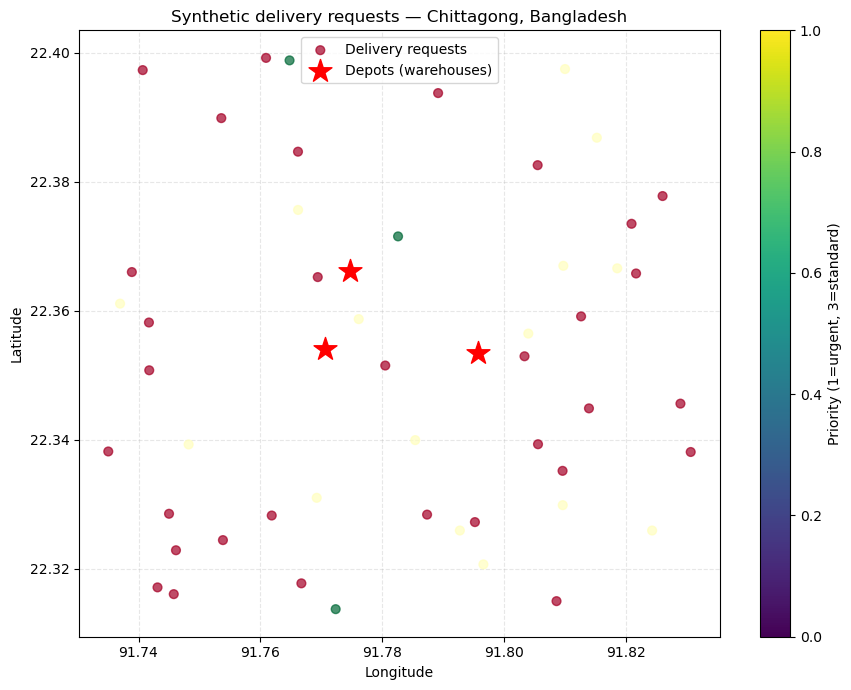

In [40]:
# Cell 3 — Scatter plot showing delivery points AND depot locations
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

# Plot customer delivery points in blue
plt.scatter(
    customers['longitude'], customers['latitude'],
    c=customers['priority'],      # colour each dot by priority level
    cmap='RdYlGn_r',             # red=urgent, green=standard
    s=40, alpha=0.7, zorder=2,
    label='Delivery requests'
)

# Plot depot locations as large red stars
plt.scatter(
    depots['longitude'], depots['latitude'],
    marker='*', s=300, color='red',
    zorder=3, label='Depots (warehouses)'
)

plt.colorbar(label='Priority (1=urgent, 3=standard)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Synthetic delivery requests — Chittagong, Bangladesh')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# Cell 4 — Summary statistics
print("--- Package weight distribution ---")
print(customers['package_weight_kg'].describe())

print("\n--- Priority breakdown ---")
print(customers['priority'].value_counts().sort_index())

print("\n--- Time window analysis ---")
customers['window_duration_mins'] = (
    customers['time_window_close'] - customers['time_window_open']
)
print(customers['window_duration_mins'].describe())

--- Package weight distribution ---
count    50.000000
mean      2.443400
std       1.458489
min       0.130000
25%       1.322500
50%       2.170000
75%       3.980000
max       4.860000
Name: package_weight_kg, dtype: float64

--- Priority breakdown ---
priority
1     3
2    15
3    32
Name: count, dtype: int64

--- Time window analysis ---
count     50.00000
mean     117.48000
std       38.95012
min       60.00000
25%       83.00000
50%      111.00000
75%      152.50000
max      179.00000
Name: window_duration_mins, dtype: float64


**Why synthetic data?**
Synthetic data lets us test routing algorithms under controlled conditions where we know the ground truth. By adjusting `num_requests`, `spread_km`, and `num_depots`, we can simulate different city scales and densities. The `seed=42` parameter ensures that anyone who clones this repository gets identical data, which is required for reproducible research.

## Part D: OSM Dataset (Chittagong)

OpenStreetMap (OSM) is a free, community-built map of the entire world. `osmnx` is a Python library that downloads a piece of that map as a graph — a network of nodes (intersections) and edges (roads/paths). For drone routing, this gives a realistic urban environment to navigate.

`pip install -r requirements.txt` run once at the beginning<br>
will handle `pip install osmnx networkx matplotlib folium`

In [42]:
import osmnx as ox        # downloads and processes OpenStreetMap data
import networkx as nx     # stores the graph of roads/paths
import os                 # for creating folders and building file paths

def load_chittagong_graph(
    place_name="Chittagong, Bangladesh",
    network_type="all",        # "all" includes roads AND footpaths (drones can fly over both)
    cache_folder="../data/osm/"
):
    """
    Downloads the road/path network for Chittagong from OpenStreetMap
    and saves it as a .graphml file so we don't have to re-download it.
    
    A graph has two components:
    - Nodes: intersections or points on the map
    - Edges: the road segments connecting them
    
    For drone delivery, we use this graph to:
    - Find the shortest path between a depot and a delivery point
    - Calculate real-world distances (not straight lines)
    - Later: add obstacle layers on top of this base graph
    
    Returns:
        G: a NetworkX graph object representing Chittagong's road network
    """
    
    # Create cache folder if it doesn't exist
    os.makedirs(cache_folder, exist_ok=True)
    
    # Build a safe filename from the place name
    # "Chittagong, Bangladesh" → "Chittagong_Bangladesh.graphml"
    safe_name = place_name.replace(", ", "_").replace(" ", "_")
    cache_path = os.path.join(cache_folder, f"{safe_name}.graphml")
    
    # --- Check if we already have the file cached ---
    # This is important: downloading from OSM can take 30–60 seconds.
    # If we already saved the file, we load it instantly from disk instead.
    if os.path.exists(cache_path):
        print(f"Loading cached graph from: {cache_path}")
        G = ox.load_graphml(cache_path)
    else:
        print(f"Downloading graph for: {place_name}")
        print("This may take 30–90 seconds depending on your internet speed...")
        
        # ox.graph_from_place downloads the entire road network for that place.
        # network_type="all" means roads, footpaths, cycleways — everything.
        G = ox.graph_from_place(place_name, network_type=network_type)
        
        # Save to disk so we never need to download again
        ox.save_graphml(G, cache_path)
        print(f"Graph saved to: {cache_path}")
    
    return G


def get_graph_stats(G):
    """
    Returns a summary of the graph's key properties.
    This is your evidence that the graph loaded correctly.
    """
    stats = {
        'num_nodes':       G.number_of_nodes(),   # intersections / decision points
        'num_edges':       G.number_of_edges(),   # road segments
        'is_directed':     nx.is_directed(G),     # True = one-way streets modelled
        'is_connected':    nx.is_weakly_connected(G),  # True = all nodes reachable
        'avg_node_degree': sum(dict(G.degree()).values()) / G.number_of_nodes()
    }
    return stats

In [44]:
# Cell 1 — Load the graph
from data_processing.load_osm import load_chittagong_graph, get_graph_stats
import osmnx as ox

G = load_chittagong_graph(
    place_name="Chittagong, Bangladesh",
    network_type="all",
    cache_folder='../datasets/osm/'
)

print("Graph loaded successfully!")

This may take 30–90 seconds depending on your internet speed...


OSError: [WinError 433] A device which does not exist was specified: '..\\notebooks\\cache\\3134e2ca7fde802d2d4b56bdb3922b52be275e76.json'

In [24]:
CITY = "Chittagong, Bangladesh"
NETWORK_TYPE = "drive"
GRAPH_PATH = "../datasets/synthetic/chittagong_graph.graphml"

if os.path.exists(GRAPH_PATH):
    G = ox.load_graphml(GRAPH_PATH)
    print(f"Loaded graph from cache: {GRAPH_PATH}")
else:
    print(f"Downloading OSM graph for {CITY}...")
    G = ox.graph_from_place(CITY, network_type=NETWORK_TYPE)
    ox.save_graphml(G, filepath=GRAPH_PATH)
    print(f"Graph saved to {GRAPH_PATH}")

c:\Users\DELL\anaconda3\Lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 26 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


ConnectTimeout: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x0000016D647A5310>, 'Connection to overpass-api.de timed out. (connect timeout=180)'))

In [ ]:
nodes, edges = ox.graph_to_gdfs(G)

print("=== Graph Summary ===")
print(f"Nodes  : {len(nodes)}")
print(f"Edges  : {len(edges)}")
print(f"CRS    : {nodes.crs}")
print()
print("=== Node Columns ===")
print(nodes.columns.tolist())
print()
print("=== Edge Columns ===")
print(edges.columns.tolist())

In [ ]:
fig, ax = ox.plot_graph(
    G,
    figsize=(14, 12),
    node_size=3,
    node_color="#3498db",
    edge_color="#95a5a6",
    edge_linewidth=0.5,
    bgcolor="#111111",
    show=False,
    close=False
)
ax.set_title(f"Road Network — {CITY}", color="white", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [ ]:
# Generate requests

import pandas as pd

requests = pd.read_csv(
    "../datasets/synthetic/requests.csv"
)

requests.head()

,request_id,source,destination,priority
0,1,Depot_A,Customer_1,High
1,2,Depot_A,Customer_2,Medium
2,3,Depot_A,Customer_3,Low
